In [1]:
#pip install pandas plotly
import plotly.io as pio
pio.renderers.default = "browser"

In [2]:
import pandas as pd
import plotly.graph_objects as go

# CSV laden
df = pd.read_csv("raw_data.csv")

# Datum converteren
df["DATE"] = pd.to_datetime(df["DATE"])
df = df.sort_values("DATE", ascending=False)

# Yield kolommen
yield_cols = [
    "Yield_1M",
    "Yield_3M",
    "Yield_6M",
    "Yield_1Y",
    "Yield_2Y",
    "Yield_3Y",
    "Yield_5Y",
    "Yield_7Y",
    "Yield_10Y",
    "Yield_20Y",
    "Yield_30Y"
]

# Maturities in jaren
maturities = [
    1/12,
    3/12,
    6/12,
    1,
    2,
    3,
    5,
    7,
    10,
    20,
    30
]

# Z matrix
Z = df[yield_cols].values.T

# Plot
fig = go.Figure(data=[go.Surface(
    z=Z,
    x=df["DATE"],
    y=maturities,
    colorscale= "Viridis" #"Cividis" #"RdBu"

)])

fig.update_layout(
    title="US Yield Curve Surface",
    scene=dict(
        xaxis=dict(
            title='Date',
            title_font=dict(size=18),
            tickfont=dict(size=14)
        ),

        yaxis=dict(
            title='Maturity',
            title_font=dict(size=18),
            tickfont=dict(size=14),
            tickvals=maturities,
            ticktext=["1M"," "," "," "," "," ","5Y"," ","10Y","20Y","30Y"]
        ),

        zaxis=dict(
            range=[0,6],
            title='Yield (%)',
            title_font=dict(size=18),
            tickfont=dict(size=14)
        ),

        aspectratio=dict(x=1, y=1, z=0.4)
    )
)
    


fig.show()

In [3]:
import pandas as pd
import plotly.graph_objects as go

# CSV laden
df = pd.read_csv("raw_data.csv")

# Datum converteren
df["DATE"] = pd.to_datetime(df["DATE"])

# Sorteren
df = df.sort_values("DATE")

# DATE als index
df = df.set_index("DATE")

# Monthly end-of-month observaties
df = df.resample("ME").last()

# Index terug kolom maken
df = df.reset_index()

# Omgekeerde volgorde indien gewenst
df = df.sort_values("DATE", ascending=False)

# Yield kolommen
yield_cols = [
    "Yield_1M",
    "Yield_3M",
    "Yield_6M",
    "Yield_1Y",
    "Yield_2Y",
    "Yield_3Y",
    "Yield_5Y",
    "Yield_7Y",
    "Yield_10Y",
    "Yield_20Y",
    "Yield_30Y"
]

# Maturities in jaren
maturities = [
    1/12,
    3/12,
    6/12,
    1,
    2,
    3,
    5,
    7,
    10,
    20,
    30
]

# Z matrix
Z = df[yield_cols].values.T

# Plot
fig = go.Figure(data=[go.Surface(
    z=Z,
    x=df["DATE"],
    y=maturities,
    colorscale="Viridis"
)])

# Layout
fig.update_layout(
    title="US Yield Curve Surface",

    scene=dict(

        xaxis=dict(
            title='Time',
            title_font=dict(size=18),
            tickfont=dict(size=14)
        ),

        yaxis=dict(
            title='Maturity',
            title_font=dict(size=18),
            tickfont=dict(size=14),
            tickvals=maturities,
            ticktext=[
                "1M"," "," "," "," "," ",
                "5Y"," ","10Y","20Y","30Y"
            ]
        ),

        zaxis=dict(
            range=[0,6],
            title='Yield (%)',
            title_font=dict(size=18),
            tickfont=dict(size=14)
        ),

        aspectratio=dict(
            x=1,
            y=1,
            z=0.4
        )
    ),

    height=800
)

fig.show()

In [4]:
# ==========================================
# 2D plots for selected maturities
# ==========================================

from plotly.subplots import make_subplots

selected_maturities = {
    "1M": "Yield_1M",
    "1Y": "Yield_1Y",
    "10Y": "Yield_10Y"
}

fig_2d = make_subplots(
    rows=1,
    cols=3,
    subplot_titles=list(selected_maturities.keys()),
    shared_yaxes=True,
    horizontal_spacing=0.06
)

for i, (label, column) in enumerate(selected_maturities.items(), start=1):

    fig_2d.add_trace(
        go.Scatter(
            x=df["DATE"],
            y=df[column],
            mode="lines",
            showlegend=False
        ),
        row=1,
        col=i
    )

    fig_2d.update_xaxes(
        title_text="Time",
        title_font=dict(size=18),
        tickfont=dict(size=14),
        row=1,
        col=i
    )

# Y-axis title only on left plot
fig_2d.update_yaxes(
    title_text="Yield (%)",
    title_font=dict(size=18),
    tickfont=dict(size=14),
    range=[0, 6],
    row=1,
    col=1
)

fig_2d.update_layout(
    title="Historical Yields for Selected Maturities",
    height=450,
    width=1200
)

fig_2d.show()

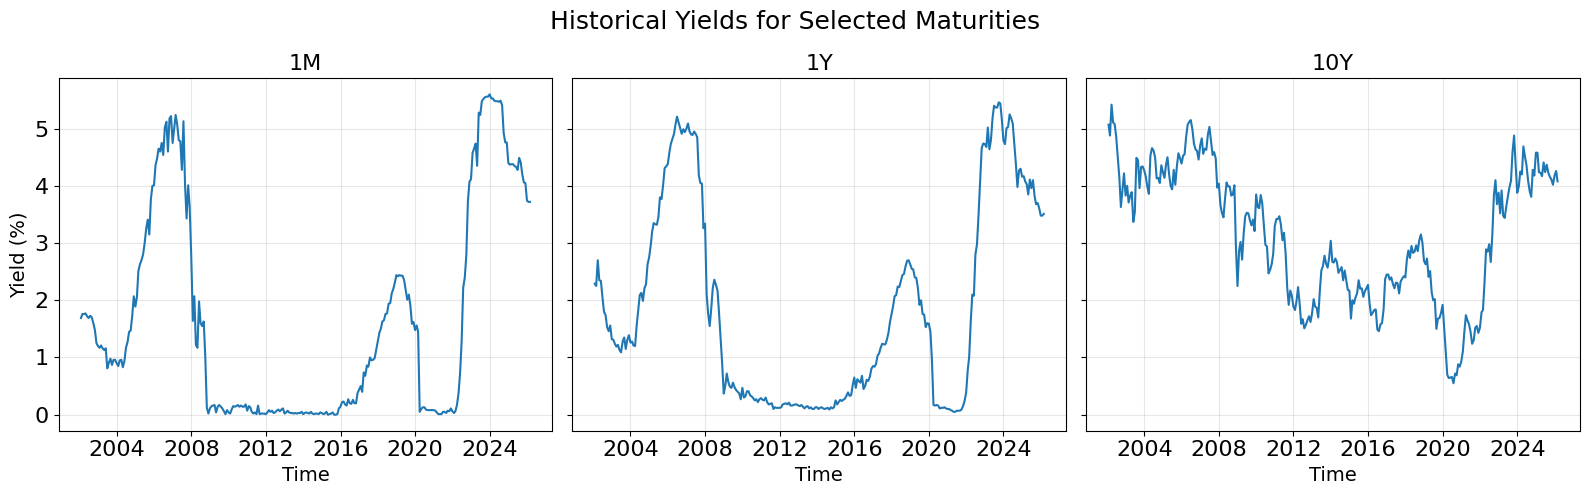

In [ ]:
import matplotlib.pyplot as plt

# Select maturities
selected = {
    "1M": "Yield_1M",
    "1Y": "Yield_1Y",
    "10Y": "Yield_10Y"
}

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5),
    sharey=True
)

for ax, (label, column) in zip(axes, selected.items()):

    ax.plot(
        df["DATE"],
        df[column],
        linewidth=1.5
    )

    ax.set_title(label, fontsize=16)
    ax.set_xlabel("Time", fontsize=16)
    ax.tick_params(axis="both", labelsize=16)
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Yield (%)", fontsize=16)

fig.suptitle(
    "Historical Yields for Selected Maturities",
    fontsize=18
)

plt.tight_layout()
plt.show()